In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
df = pd.read_csv("TARP.csv")

In [ ]:
#Just to check the dataset and see the columns
print(df.head())
print(df.info())
print(df.describe())

   Soil Moisture  Temperature   Soil Humidity  Time  Air temperature (C)  \
0             54           22              70    21                19.52   
1             12           20              40   104                19.49   
2             34           26              35    62                19.47   
3              7           44              44    93                19.54   
4             50           38              23    92                19.61   

   Wind speed (Km/h)  Air humidity (%)  Wind gust (Km/h)  Pressure (KPa)  \
0               2.13             55.04              6.30          101.50   
1               2.01             55.17             10.46          101.50   
2               1.90             55.30             14.63          101.51   
3               2.28             54.20             16.08          101.51   
4               2.66             53.09             17.52          101.51   

         ph    rainfall     N     P     K Status  
0  6.502985  202.935536  90.0  42.0

In [ ]:
#Check for missing values
print(df.isnull().sum())

Soil Moisture              0
Temperature                0
 Soil Humidity             0
Time                       0
Air temperature (C)    76005
Wind speed (Km/h)      76005
Air humidity (%)       76005
Wind gust (Km/h)       76005
Pressure (KPa)         76005
ph                     97800
rainfall               97800
N                      97800
P                      97800
K                      97800
Status                     0
dtype: int64


In [ ]:
#Total no. of rows before removing missing values
print(f"Total number of rows: {df.shape[0]}")

Total number of rows: 100000


In [ ]:
#drop rows with missing values
df = df.dropna()

In [ ]:
# Fill missing values only in numeric columns with their respective means
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())


In [ ]:
#Total no. of rows after removing missing values
print(f"Total number of rows: {df.shape[0]}")

Total number of rows: 2200


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(f"Total number of rows: {df.shape[0]}")

Total number of rows: 2200


In [ ]:
#Check target value
print(df['Status'].value_counts())

Status
ON     1176
OFF    1024
Name: count, dtype: int64


In [ ]:
#Encode variable to binary (ON-> 1 OFF-> 0)
le = LabelEncoder()

df['Status'] = le.fit_transform(df['Status'])

In [ ]:
#Separate Features and Target
X = df.drop('Status', axis=1)
y = df['Status']

In [ ]:
#Feature Scaling (Standardization (Z-score Normalization))
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

#Three Models will be trained
#i. Logistic Regression
#ii. Random Forest
#iii. XGBoost


#First model -- Logistic Regression

In [ ]:
#First model -- Logistic Regression



import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# 2. Load Dataset


df = pd.read_csv("TARP.csv")
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()


# 3. Select Required Features

features = [
    "Soil Moisture",
    "Temperature",
    "Soil Humidity", # Removed leading space as column names are now stripped
    "Air temperature (C)",
    "Wind speed (Km/h)",
    "Air humidity (%)", # Removed trailing space
    "ph",                 # Removed trailing space
    "rainfall"            # Removed trailing space
]

X = df[features]

# Target variable
y = df["Status"]

# 4. Handle Missing Values
# Fill missing values with column mean
X = X.fillna(X.mean())


# 5. Encode Target Variable
# Convert ON/OFF into 1/0

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)


# 6. Feature Scaling
# Standardize feature values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


# 8. Model Training
# Create Logistic Regression model

model = LogisticRegression()

# Train the model

model.fit(X_train, y_train)

print("Model Training Completed")


# 9. Model Prediction
y_pred = model.predict(X_test)

# 10. Model Evaluation
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report

report = classification_report(y_test, y_pred)

print("\nClassification Report:")
print(report)


Model Training Completed

Accuracy Score:
0.6944

Confusion Matrix:
[[5933 3372]
 [2740 7955]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.64      0.66      9305
           1       0.70      0.74      0.72     10695

    accuracy                           0.69     20000
   macro avg       0.69      0.69      0.69     20000
weighted avg       0.69      0.69      0.69     20000



### Feature Importance from Logistic Regression Coefficients

For Logistic Regression, the absolute values of the coefficients can be used to infer feature importance. A larger absolute coefficient value indicates a stronger impact of that feature on the target variable. Since the features were scaled using `StandardScaler`, the coefficients are directly comparable.

/tmp/ipykernel_635/2351057125.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


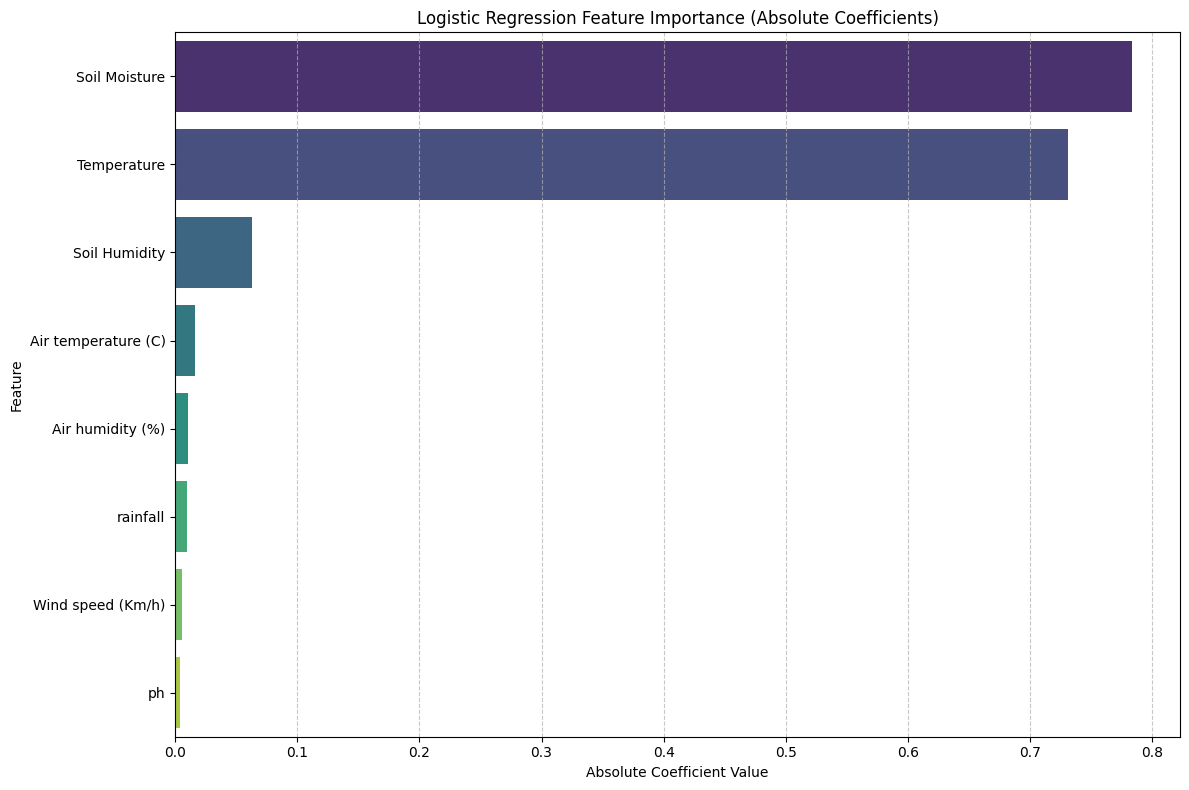

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from the original DataFrame X
feature_names = X.columns

# Get the coefficients from the trained Logistic Regression model
coefficients = model.coef_[0]

# Create a DataFrame to store feature importance
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': np.abs(coefficients)})

# Sort features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Logistic Regression Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#Second model -- Random Forest

Random Forest Model Training Completed

Accuracy Score:
0.7078

Confusion Matrix:
[[6060 3245]
 [2599 8096]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.65      0.67      9305
           1       0.71      0.76      0.73     10695

    accuracy                           0.71     20000
   macro avg       0.71      0.70      0.70     20000
weighted avg       0.71      0.71      0.71     20000



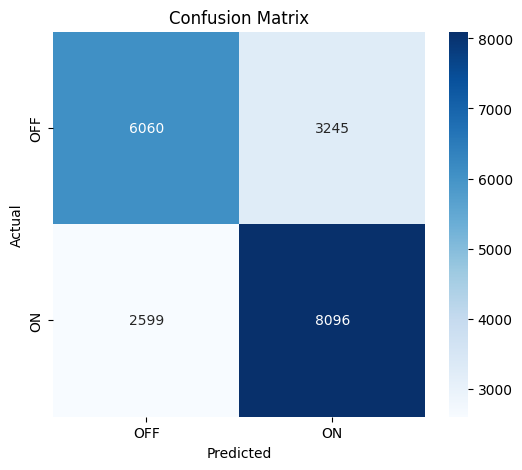

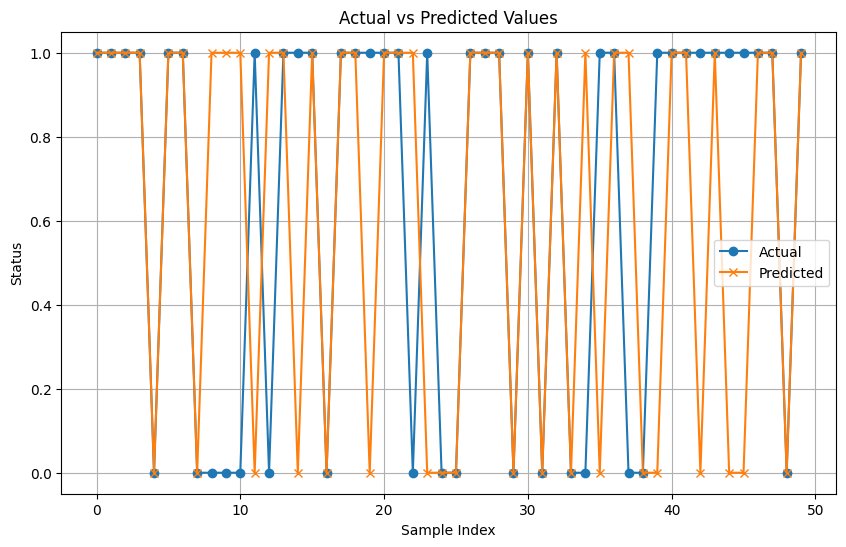

In [ ]:
# Random Forest Classification for Irrigation Prediction



# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# 2. Load Dataset

df = pd.read_csv("TARP.csv")
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()


# 3. Select Features and Target


features = [
    "Soil Moisture",
    "Temperature",
    "Soil Humidity", # Removed leading space
    "Air temperature (C)",
    "Wind speed (Km/h)",
    "Air humidity (%)", # Removed trailing space
    "ph",                 # Removed trailing space
    "rainfall"            # Removed trailing space
]

X = df[features]

y = df["Status"]

# 4. Handle Missing Values


X = X.fillna(X.mean())


# 5. Encode Target Variable

# Convert ON/OFF into 1/0

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)


# 6. Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# i) MODEL TRAINING
# 7. Create Random Forest Model


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# 8. Train the Model

rf_model.fit(X_train, y_train)

print("Random Forest Model Training Completed")


# ii) MODEL EVALUATION
# 9. Make Predictions


y_pred = rf_model.predict(X_test)


# 10. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)


# 11. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# 12. Classification Report
report = classification_report(y_test, y_pred)

print("\nClassification Report:")
print(report)


# iii) PLOT EVALUATION MATRICES

# 13. Plot Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['OFF', 'ON'],
    yticklabels=['OFF', 'ON']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 14. Actual vs Predicted Graph

plt.figure(figsize=(10,6))

plt.plot(y_test[:50], label='Actual', marker='o')

plt.plot(y_pred[:50], label='Predicted', marker='x')

plt.title("Actual vs Predicted Values")

plt.xlabel("Sample Index")

plt.ylabel("Status")

plt.legend()

plt.grid(True)

plt.show()


#Third model -- XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:22:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Model Training Completed

Accuracy Score:
0.7374

Confusion Matrix:
[[6384 2921]
 [2331 8364]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.69      0.71      9305
           1       0.74      0.78      0.76     10695

    accuracy                           0.74     20000
   macro avg       0.74      0.73      0.73     20000
weighted avg       0.74      0.74      0.74     20000



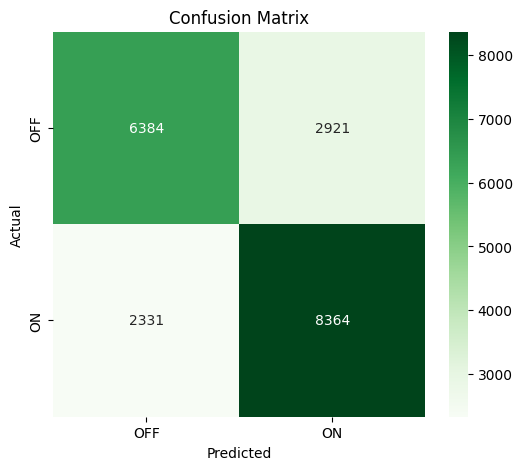

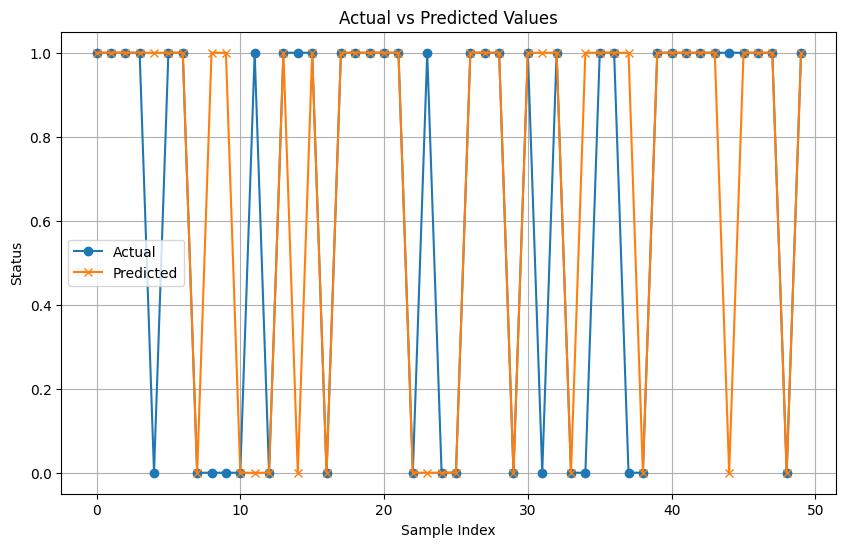

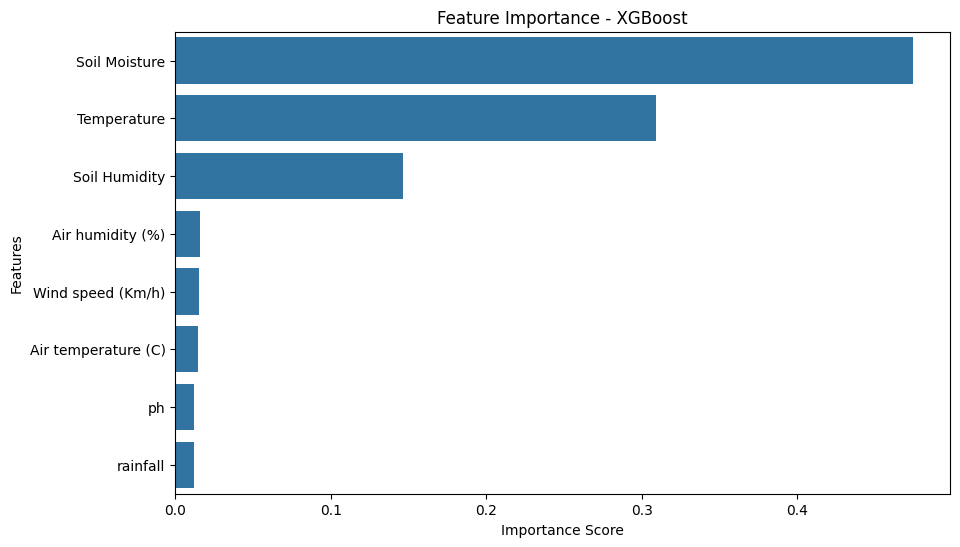

In [ ]:
# XGBoost Classification for Irrigation Prediction


# 1. Import Required Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# 2. Load Dataset
df = pd.read_csv("TARP.csv")
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# 3. Select Features and Target

features = [
    "Soil Moisture",
    "Temperature",
    "Soil Humidity", # Removed leading space
    "Air temperature (C)",
    "Wind speed (Km/h)",
    "Air humidity (%)", # Removed trailing space
    "ph",                 # Removed trailing space
    "rainfall"            # Removed trailing space
]

X = df[features]

y = df["Status"]


# 4. Handle Missing Values
X = X.fillna(X.mean())

# 5. Encode Target Variable
# Convert ON/OFF into 1/0

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)


# 6. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# i) MODEL TRAINING
# 7. Create XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


# 8. Train the Model
xgb_model.fit(X_train, y_train)

print("XGBoost Model Training Completed")

# ii) MODEL EVALUATION

# 9. Make Predictions
y_pred = xgb_model.predict(X_test)


# 10. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

# 11. Confusion Matrix


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# 12. Classification Report
report = classification_report(y_test, y_pred)

print("\nClassification Report:")
print(report)

# iii) PLOT EVALUATION MATRICES
# 13. Plot Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['OFF', 'ON'],
    yticklabels=['OFF', 'ON']
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# 14. Actual vs Predicted Graph

plt.figure(figsize=(10,6))

plt.plot(y_test[:50], label='Actual', marker='o')

plt.plot(y_pred[:50], label='Predicted', marker='x')

plt.title("Actual vs Predicted Values")

plt.xlabel("Sample Index")

plt.ylabel("Status")

plt.legend()

plt.grid(True)

plt.show()


# 15. Feature Importance Plot

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - XGBoost")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

#Compare all the models


--- Model Performance Comparison ---

                 Model  Accuracy
2              XGBoost    0.7374
1        Random Forest    0.7078
0  Logistic Regression    0.6944




/tmp/ipykernel_635/3306627244.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=performance_df, palette='viridis')


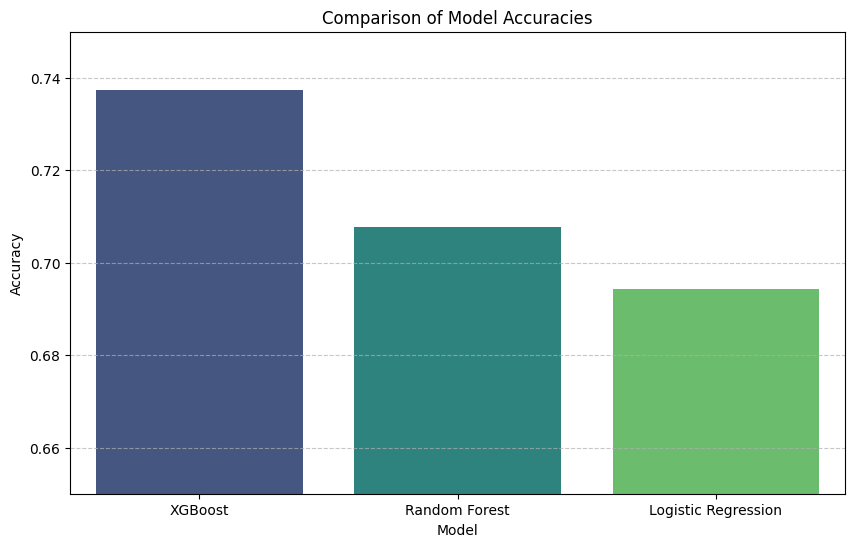

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming the accuracy scores for each model are available from previous executions
# For demonstration, I will use the values observed in the chat history.
logistic_regression_accuracy = 0.6944
random_forest_accuracy = 0.7078
xgboost_accuracy = 0.7374

# Create a DataFrame to store the model performance
performance_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [logistic_regression_accuracy, random_forest_accuracy, xgboost_accuracy]
}

performance_df = pd.DataFrame(performance_data)

# Sort by accuracy for better visualization
performance_df = performance_df.sort_values(by='Accuracy', ascending=False)

print("\n--- Model Performance Comparison ---\n")
print(performance_df)
print("\n")

# Plotting the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=performance_df, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.65, 0.75) # Set y-axis limits to better highlight differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()